# ‘Pent-Up’ Frustration 3 / Knight Moves 7

T   he board above has been tiled with the 12 pentominoes (plus a 2-by-2 tetromino) into 13 regions. Think of each of these 13 regions as constructed out of 1-by-1-by-1 cubes. We need to add a tower to each region. A tower is an additional size-1 cube placed on one of a region’s squares.

After adding these towers, place a knight at the bottom-left square. It then proceeds to make knight’s moves until it has visited all the towers. It never visits the same space twice. (A move on this board involves travelling 0 units in one dimension, 1 in another, and 2 in the third. The knight is allowed to “pass through” towers as it moves.)

But there’s a catch: As you can see, the knight starts with a score of 0. On its Nth move, its score increases by N if the move is to a location at the same altitude as the square it moved from. If, instead, it moves up, the score is multiplied by N. And finally, if it moves down, the score is divided by N. This last type of move is only allowed if the score is evenly divisible by N.

Every three moves, up until move #18, the knight wrote down its score upon arriving at a given square. From then on it only wrote down its score every K moves, for some larger value K. Using this information, can you reconstruct the knight’s path?



After filling all the remaining visited squares with the missing score values, find the unvisited squares. For each of these squares, compute the sum of the scores in any orthogonally adjacent squares that were part of the knight’s path. The answer to this puzzle is the sum of these “neighbor sums” from the unvisited squares.

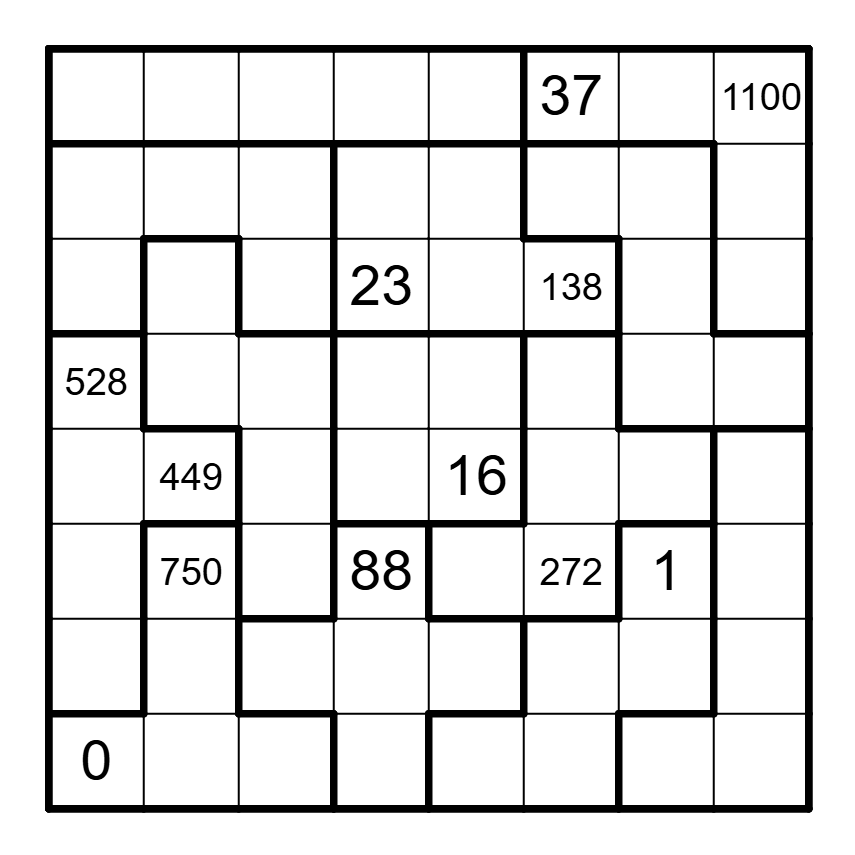

In [1]:
from itertools import permutations, chain
from copy import deepcopy

In [2]:
regions = [
    [1, 1, 1, 1, 1, 2, 2, 2],
    [3, 3, 3, 4, 4, 5, 5, 2],
    [3, 6, 3, 4, 4, 4, 5, 2],
    [7, 6, 6, 8, 8, 9, 5, 5],
    [7, 7, 6, 8, 8, 9, 9, 10],
    [7, 11, 6, 12, 9, 9, 13, 10],
    [7, 11, 12, 12, 12, 13, 13, 10],
    [11, 11, 11, 12, 13, 13, 10, 10]
]

marked_points = [
    [-1, -1, -1, -1, -1, 37, -1, 1100],
    [-1, -1, -1, -1, -1, -1, -1, -1],
    [-1, -1, -1, 23, -1, 138, -1, -1],
    [528, -1, -1, -1, -1, -1, -1, -1],
    [-1, 449, -1, -1, 16, -1, -1, -1],
    [-1, 750, -1, 88, -1, 272, 1, -1],
    [-1, -1, -1, -1, -1, -1, -1, -1],
    [0, -1, -1, -1, -1, -1, -1, -1]
]

In [ ]:
class Position():
    def __init__(self, x: int, y: int, z: int):
        self.x = x
        self.y = y
        self.z = z

    def __repr__(self):
        return f"({self.x}, {self.y}, {self.z})"

    def __sub__(self, other):
        if isinstance(other, Position):
            return Position(self.x - other.x, self.y - other.y, self.z - other.z)
        
        raise TypeError("Operand must be of type Position")

    def __rsub__(self, other):
        if isinstance(other, Position):
            return Position(other.x - self.x, other.y - self.y, other.z - self.z)
        
        raise TypeError("Operand must be of type Position")

    def __add__(self, other):
        if isinstance(other, Position):
            return Position(other.x + self.x, other.y + self.y, other.z + self.z)
        
        raise TypeError("Operand must be of type Position")

    def __eq__(self, other):
        return (self.x == other.x) and (self.y == other.y) and (self.z == other.z)

    def __hash__(self):
        return hash((self.x, self.y, self.z))

In [ ]:
class Board():
    def __init__(self, regions: list[list[int]], marked_points: list[list[int]]):
        self.regions = regions
        self.marked_points = marked_points
        self.visited_squares = [Position(0, 0, 1)]
        self.towered_regions = [11]
        self.found_points = [0]
        self.board_size = len(regions) - 1 # Assuming it's always square
        self.knight_position = Position(0, 0, 1) # Knight starts up a tower (Found out by trying every possibility with it down the tower)
        self.points = 0
        self.movements_count = 0
        self.position_to_points = {Position(0, 0, 1): 0}
        self.k = 7 # Found this by finding the 25th marked point, so did 25 - 18 to find that K is 7

    def __repr__(self):
        return f'''Knight position: {self.knight_position}
 Current Points: {self.points}
Movements count: {self.movements_count}
   Found points: {self.found_points} ({len(self.found_points)})
 Reached towers: {self.towered_regions} ({len(self.towered_regions)})'''

    def __deepcopy__(self, memo):
        copy = type(self).__new__(type(self))
        memo[id(self)] = copy
        for name, value in self.__dict__.items():
            setattr(copy, name, deepcopy(value, memo))
        return copy
    
    def print_grid(self):
        for y in range(self.board_size + 1):
            for x in range(self.board_size + 1):
                cur_pos_tower = Position(x, self.board_size - y, 1)

                if cur_pos_tower in self.visited_squares:
                    # It's a tower
                    char = 'X'
                else:
                    # It's a normal square
                    char = '■'
                
                print(f"\033[1;{31 + self.get_region_from_position(cur_pos_tower) % 9}m{char}\033[0m", end=' ')
            print()

    def get_marked_points_from_position(self, position: Position):
        return self.marked_points[self.board_size - position.y][position.x]

    def get_region_from_position(self, position: Position):
        return self.regions[self.board_size - position.y][position.x]

    def _check_valid_position(self, position: Position):
        return not (
            (Position(position.x, position.y, 0) in self.visited_squares or Position(position.x, position.y, 1) in self.visited_squares)                           # Square/Tower has been visited
            or position.z >= 2                                                                                                                                     # Going up too high
            or max(position.x, position.y, position.z) > self.board_size                                                                                           # Going off bounds
            or min(position.x, position.y, position.z) < 0                                                                                                         # Going off bounds
            or (self.get_marked_points_from_position(position) != self.get_points_for_movement(position) and self.get_marked_points_from_position(position) != -1) # Going to a marked spot without the said amount of points
            or (self.get_region_from_position(position) in self.towered_regions) and (position.z == 1)                                                             # Trying to build another tower in a towered region
            or (self.get_marked_points_from_position(position) != -1 and (self.movements_count + 1) % 3 != 0 and (self.movements_count + 1) <= 18)                 # Going into a marked spot on a non multiple of 3 below move 18
            or (self.get_marked_points_from_position(position) == -1 and (self.movements_count + 1) % 3 == 0 and (self.movements_count + 1) <= 18)                 # Going into a non-marked spot on a multiple of 3 below move 18
            or (self.get_marked_points_from_position(position) != -1 and (self.movements_count + 1 - 18) % self.k != 0 and (self.movements_count + 1) > 18)        # Going into a marked spot on a non multiple of k above move 18
            or (self.get_marked_points_from_position(position) == -1 and (self.movements_count + 1 - 18) % self.k == 0 and (self.movements_count + 1) > 18)        # Going into a non-marked spot on a multiple of k above move 18
            or (len(self.towered_regions) >= 13)                                                                                                                   # Visited all towers
            or (self.get_points_for_movement(position) != round(self.get_points_for_movement(position)))                                                           # Going downwards on a non-integer division
        )

    def get_valid_neighbors(self):
        triplets = [
            (-2, -1, 0),
            (2, -1, 0),
            (2, 1, 0),
            (-2, 1, 0)
        ]
        neighbors = []

        for delta in chain.from_iterable(permutations(t) for t in triplets):
            neighbor = Position(
                self.knight_position.x + delta[0],
                self.knight_position.y + delta[1],
                self.knight_position.z + delta[2]
            )

            if self._check_valid_position(neighbor):
                neighbors.append(neighbor)

        return neighbors

    def get_points_for_movement(self, destination: Position):
        delta = destination - self.knight_position
        n = self.movements_count + 1

        # Goes up a tower
        if delta.z >= 1:
            return self.points * n

        # Stays on the floor
        elif delta.z == 0:
            return self.points + n

        # Goes down a tower
        elif delta.z <= -1:
            return self.points / n

    def make_movement(self, destination: Position):
        if not self._check_valid_position(destination):
            raise ValueError("Invalid position")

        self.points = self.get_points_for_movement(destination)
        self.movements_count += 1
        self.knight_position = destination
        self.visited_squares.append(destination)
        self.position_to_points[destination] = self.points

        # Set tower
        if self.knight_position.z == 1:
            self.towered_regions.append(self.get_region_from_position(destination))

        if self.get_marked_points_from_position(destination) != -1:
            self.found_points.append(self.points)

        if len(self.found_points) == 12 and len(self.towered_regions) == 13:
            print('Found answer!')
            print()
            print(self.visited_squares)
            print(self)
            self.print_grid()

    def get_answer_from_board(self):
        triplets = [
            (1, 0, 0),
            (-1, 0, 0),
            (0, 1, 0),
            (0, -1, 0),
        ]

        answer = 0
        
        for y in range(self.board_size + 1):
            for x in range(self.board_size + 1):
                cur_pos = Position(x, self.board_size - y, 0)
                cur_pos_tower = Position(x, self.board_size - y, 1)

                # For unvisited
                if cur_pos not in self.visited_squares and cur_pos_tower not in self.visited_squares:

                    # Get orthogonally adjacent
                    for triplet in triplets:
                        delta = Position(triplet[0], triplet[1], triplet[2])
                        answer += self.position_to_points.get(cur_pos + delta, 0)
                        answer += self.position_to_points.get(cur_pos_tower + delta, 0)

        return answer


In [5]:
brute_board = Board(regions, marked_points)

def tree_brute(current: int, limit: int, board: Board):
    if current >= limit:
        return

    for neighbor in board.get_valid_neighbors():
        board_copy = deepcopy(board)
        board_copy.make_movement(neighbor)

        tree_brute(current + 1, limit, board_copy)

In [6]:
tree_brute(0, 53 + 6, brute_board) # Trying every possibility with 18 + 7 * 5 + 6, given that there are 18 first moves, 7 * 5 with K = 7, and there could possibly be 6 more that isn't marked

Found answer!

[(0, 0, 1), (2, 1, 1), (4, 2, 1), (6, 2, 0), (7, 0, 0), (5, 1, 0), (4, 3, 0), (4, 5, 1), (4, 7, 0), (3, 5, 0), (2, 7, 0), (0, 6, 0), (0, 4, 1), (1, 6, 1), (3, 7, 1), (5, 7, 0), (3, 6, 0), (2, 4, 0), (3, 2, 0), (1, 1, 0), (0, 3, 0), (2, 3, 1), (4, 4, 1), (5, 6, 1), (7, 6, 0), (5, 5, 0), (3, 4, 0), (2, 2, 0), (0, 1, 0), (2, 0, 0), (4, 0, 1), (6, 0, 0), (5, 2, 0), (7, 2, 1), (7, 4, 0), (6, 6, 0), (5, 4, 0), (4, 6, 0), (2, 5, 0), (1, 3, 0), (0, 5, 0), (2, 6, 0), (1, 4, 0), (0, 2, 0), (1, 0, 0), (3, 1, 0), (1, 2, 0), (3, 3, 0), (4, 1, 0), (5, 3, 0), (6, 1, 0), (7, 3, 0), (6, 5, 0), (7, 7, 0), (7, 5, 1)]
Knight position: (7, 5, 1)
 Current Points: 59400.0
Movements count: 54
   Found points: [0, 1.0, 16.0, 23.0, 528.0, 37.0, 88.0, 138.0, 272.0, 449.0, 750.0, 1100.0] (12)
 Reached towers: [11, 12, 9, 4, 7, 3, 1, 6, 8, 5, 13, 10, 2] (13)
■ ■ ■ X ■ ■ ■ ■ 
■ X ■ ■ ■ X ■ ■ 
■ ■ ■ ■ X ■ ■ X 
X ■ ■ ■ X ■ ■ ■ 
■ ■ X ■ ■ ■ ■ ■ 
■ ■ ■ ■ X ■ ■ X 
■ ■ X ■ ■ ■ ■ ■ 
X ■ ■ ■ X ■ ■ ■ 


In [7]:
answer_sequence = [(0, 0, 1), (2, 1, 1), (4, 2, 1), (6, 2, 0), (7, 0, 0), (5, 1, 0), (4, 3, 0), (4, 5, 1), (4, 7, 0), (3, 5, 0), (2, 7, 0), (0, 6, 0), (0, 4, 1), (1, 6, 1), (3, 7, 1), (5, 7, 0), (3, 6, 0), (2, 4, 0), (3, 2, 0), (1, 1, 0), (0, 3, 0), (2, 3, 1), (4, 4, 1), (5, 6, 1), (7, 6, 0), (5, 5, 0), (3, 4, 0), (2, 2, 0), (0, 1, 0), (2, 0, 0), (4, 0, 1), (6, 0, 0), (5, 2, 0), (7, 2, 1), (7, 4, 0), (6, 6, 0), (5, 4, 0), (4, 6, 0), (2, 5, 0), (1, 3, 0), (0, 5, 0), (2, 6, 0), (1, 4, 0), (0, 2, 0), (1, 0, 0), (3, 1, 0), (1, 2, 0), (3, 3, 0), (4, 1, 0), (5, 3, 0), (6, 1, 0), (7, 3, 0), (6, 5, 0), (7, 7, 0), (7, 5, 1)]
answer_board = Board(regions, marked_points)

for movement in answer_sequence[1:]:
    position = Position(movement[0], movement[1], movement[2])
    answer_board.make_movement(position)

print()

print('FINAL ANSWER:', int(answer_board.get_answer_from_board()))

Found answer!

[(0, 0, 1), (2, 1, 1), (4, 2, 1), (6, 2, 0), (7, 0, 0), (5, 1, 0), (4, 3, 0), (4, 5, 1), (4, 7, 0), (3, 5, 0), (2, 7, 0), (0, 6, 0), (0, 4, 1), (1, 6, 1), (3, 7, 1), (5, 7, 0), (3, 6, 0), (2, 4, 0), (3, 2, 0), (1, 1, 0), (0, 3, 0), (2, 3, 1), (4, 4, 1), (5, 6, 1), (7, 6, 0), (5, 5, 0), (3, 4, 0), (2, 2, 0), (0, 1, 0), (2, 0, 0), (4, 0, 1), (6, 0, 0), (5, 2, 0), (7, 2, 1), (7, 4, 0), (6, 6, 0), (5, 4, 0), (4, 6, 0), (2, 5, 0), (1, 3, 0), (0, 5, 0), (2, 6, 0), (1, 4, 0), (0, 2, 0), (1, 0, 0), (3, 1, 0), (1, 2, 0), (3, 3, 0), (4, 1, 0), (5, 3, 0), (6, 1, 0), (7, 3, 0), (6, 5, 0), (7, 7, 0), (7, 5, 1)]
Knight position: (7, 5, 1)
 Current Points: 59400.0
Movements count: 54
   Found points: [0, 1.0, 16.0, 23.0, 528.0, 37.0, 88.0, 138.0, 272.0, 449.0, 750.0, 1100.0] (12)
 Reached towers: [11, 12, 9, 4, 7, 3, 1, 6, 8, 5, 13, 10, 2] (13)
■ ■ ■ X ■ ■ ■ ■ 
■ X ■ ■ ■ X ■ ■ 
■ ■ ■ ■ X ■ ■ X 
X ■ ■ ■ X ■ ■ ■ 
■ ■ X ■ ■ ■ ■ ■ 
■ ■ ■ ■ X ■ ■ X 
■ ■ X ■ ■ ■ ■ ■ 
X ■ ■ ■ X ■ ■ ■ 

FINAL 